In [1]:
import pandas as pd
import numpy as np

from pathlib import Path
import joblib
import warnings

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

BASE_DIR = Path("..")
PROCESSED_DIR = BASE_DIR / "data" / "processed"
RESULTS_DIR = BASE_DIR / "results"
TABLES_DIR = RESULTS_DIR / "tables"
MODELS_DIR = RESULTS_DIR / "models"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

input_path = PROCESSED_DIR / "housing_dataset_europe_features.csv"

df = pd.read_csv(input_path)
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["date", "country"]).reset_index(drop=True)

df.head()

,date,country,year,quarter,hpi,hpi_target_1q,hicp,inflation_yoy,unemployment_rate,housing_overburden_rate,...,unemployment_rate_lag_1,unemployment_rate_lag_4,housing_overburden_rate_lag_1,housing_overburden_rate_lag_4,ecb_main_refinancing_rate_lag_1,ecb_main_refinancing_rate_lag_4,unemployment_change_1q,inflation_change_1q,ecb_rate_change_1q,hpi_target_1q_growth
0,2015-01-01,Alemania,2015,1,97.80,99.90,98.933333,-0.134590,4.5,15.6,...,4.6,4.8,15.9,15.9,0.05,0.25,-0.1,-0.572743,0.0,2.147239
1,2015-01-01,Austria,2015,1,98.19,99.97,99.126667,0.625994,6.0,6.4,...,6.1,6.1,6.6,6.6,0.05,0.25,-0.1,-0.628614,0.0,1.812812
2,2015-01-01,Bulgaria,2015,1,98.85,99.71,99.950000,-1.733630,10.9,14.8,...,11.7,13.3,12.9,12.9,0.05,0.25,-0.8,0.046263,0.0,0.870005
3,2015-01-01,Bélgica,2015,1,97.94,99.13,98.860000,-0.386256,8.9,9.4,...,8.7,8.8,10.4,10.4,0.05,0.25,0.2,-0.382901,0.0,1.215030
4,2015-01-01,Chequia,2015,1,98.30,99.40,99.633333,0.000000,5.7,10.4,...,5.8,6.5,10.5,10.5,0.05,0.25,-0.1,-0.470430,0.0,1.119023


In [2]:
def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    denominator = np.where(denominator == 0, 1e-8, denominator)

    return np.mean(np.abs(y_true - y_pred) / denominator) * 100

In [3]:
TARGET = "hpi_target_1q"

numeric_features = [
    "year",
    "quarter",

    "hpi",
    "inflation_yoy",
    "unemployment_rate",
    "housing_overburden_rate",
    "ecb_main_refinancing_rate",

    "hpi_lag_1",
    "hpi_lag_2",
    "hpi_lag_4",

    "hpi_qoq_growth",
    "hpi_yoy_growth",

    "hpi_rolling_mean_4",
    "hpi_rolling_std_4",

    "inflation_yoy_lag_1",
    "inflation_yoy_lag_4",

    "unemployment_rate_lag_1",
    "unemployment_rate_lag_4",

    "housing_overburden_rate_lag_1",
    "housing_overburden_rate_lag_4",

    "ecb_main_refinancing_rate_lag_1",
    "ecb_main_refinancing_rate_lag_4",

    "unemployment_change_1q",
    "inflation_change_1q",
    "ecb_rate_change_1q"
]

categorical_features = ["country"]

feature_cols = numeric_features + categorical_features

len(feature_cols), feature_cols

(26,
 ['year',
  'quarter',
  'hpi',
  'inflation_yoy',
  'unemployment_rate',
  'housing_overburden_rate',
  'ecb_main_refinancing_rate',
  'hpi_lag_1',
  'hpi_lag_2',
  'hpi_lag_4',
  'hpi_qoq_growth',
  'hpi_yoy_growth',
  'hpi_rolling_mean_4',
  'hpi_rolling_std_4',
  'inflation_yoy_lag_1',
  'inflation_yoy_lag_4',
  'unemployment_rate_lag_1',
  'unemployment_rate_lag_4',
  'housing_overburden_rate_lag_1',
  'housing_overburden_rate_lag_4',
  'ecb_main_refinancing_rate_lag_1',
  'ecb_main_refinancing_rate_lag_4',
  'unemployment_change_1q',
  'inflation_change_1q',
  'ecb_rate_change_1q',
  'country'])

In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [5]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge alpha=0.1": Ridge(alpha=0.1),
    "Ridge alpha=1": Ridge(alpha=1.0),
    "Ridge alpha=10": Ridge(alpha=10.0),

    "Lasso alpha=0.001": Lasso(alpha=0.001, max_iter=20000),
    "Lasso alpha=0.01": Lasso(alpha=0.01, max_iter=20000),
    "Lasso alpha=0.1": Lasso(alpha=0.1, max_iter=20000),
}

try:
    from xgboost import XGBRegressor

    models["XGBoost"] = XGBRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

except ModuleNotFoundError:
    print("XGBoost no está instalado. Se omite.")

models.keys()

dict_keys(['Linear Regression', 'Ridge alpha=0.1', 'Ridge alpha=1', 'Ridge alpha=10', 'Lasso alpha=0.001', 'Lasso alpha=0.01', 'Lasso alpha=0.1', 'XGBoost'])

In [6]:
def global_temporal_backtest(
    data,
    models,
    feature_cols,
    target_col,
    min_train_date="2016-01-01"
):
    results = []
    predictions = []

    dates = sorted(data["date"].unique())
    min_train_date = pd.to_datetime(min_train_date)

    test_dates = [d for d in dates if d >= min_train_date]

    for model_name, model in models.items():

        print(f"Evaluando modelo: {model_name}")

        y_true_all = []
        y_pred_all = []
        dates_all = []
        countries_all = []

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        for test_date in test_dates:

            train = data[data["date"] < test_date].copy()
            test = data[data["date"] == test_date].copy()

            if len(train) == 0 or len(test) == 0:
                continue

            X_train = train[feature_cols]
            y_train = train[target_col]

            X_test = test[feature_cols]
            y_test = test[target_col]

            pipeline.fit(X_train, y_train)

            preds = pipeline.predict(X_test)

            y_true_all.extend(y_test.values)
            y_pred_all.extend(preds)
            dates_all.extend(test["date"].values)
            countries_all.extend(test["country"].values)

        results.append({
            "model": model_name,
            "MAE": mae(y_true_all, y_pred_all),
            "RMSE": rmse(y_true_all, y_pred_all),
            "sMAPE": smape(y_true_all, y_pred_all)
        })

        model_predictions = pd.DataFrame({
            "date": dates_all,
            "country": countries_all,
            "real": y_true_all,
            "predicted": y_pred_all,
            "model": model_name
        })

        predictions.append(model_predictions)

    results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
    predictions_df = pd.concat(predictions, ignore_index=True)

    return results_df, predictions_df

In [7]:
global_results, global_predictions = global_temporal_backtest(
    data=df,
    models=models,
    feature_cols=feature_cols,
    target_col=TARGET,
    min_train_date="2020-01-01"
)

global_results

Evaluando modelo: Linear Regression
Evaluando modelo: Ridge alpha=0.1
Evaluando modelo: Ridge alpha=1
Evaluando modelo: Ridge alpha=10
Evaluando modelo: Lasso alpha=0.001
Evaluando modelo: Lasso alpha=0.01
Evaluando modelo: Lasso alpha=0.1
Evaluando modelo: XGBoost


,model,MAE,RMSE,sMAPE
0,Lasso alpha=0.1,2.597126,3.723600,1.560418
1,Lasso alpha=0.01,2.993608,4.430736,1.801601
2,Ridge alpha=10,3.050060,4.350987,1.835110
3,Ridge alpha=0.1,3.084561,4.487840,1.869333
4,Lasso alpha=0.001,3.095358,4.495607,1.874157
5,Ridge alpha=1,3.108945,4.516447,1.875800
6,Linear Regression,3.163923,4.578518,1.917652
7,XGBoost,3.471730,5.732416,1.944623


In [8]:
best_model_name = global_results.iloc[0]["model"]

best_predictions = global_predictions[
    global_predictions["model"] == best_model_name
].copy()

country_metrics = (
    best_predictions
    .groupby("country")
    .apply(
        lambda x: pd.Series({
            "MAE": mae(x["real"], x["predicted"]),
            "RMSE": rmse(x["real"], x["predicted"]),
            "sMAPE": smape(x["real"], x["predicted"])
        })
    )
    .reset_index()
    .sort_values("MAE")
)

country_metrics

,country,MAE,RMSE,sMAPE
3,Bélgica,1.409992,1.899500,1.051000
13,Francia,1.413501,1.755206,1.103682
12,Finlandia,1.563395,2.150985,1.482130
10,España,1.632135,2.167821,1.115466
16,Italia,1.633242,2.325360,1.526322
20,Malta,1.670284,2.195169,1.121403
15,Irlanda,1.720444,2.149749,1.061638
24,Rumanía,1.946257,2.461402,1.352506
7,Dinamarca,2.052726,2.445157,1.476526
23,Portugal,2.138828,2.642271,1.046009


In [9]:
global_results.to_csv(
    TABLES_DIR / "global_model_europe_results.csv",
    index=False
)

global_predictions.to_csv(
    TABLES_DIR / "global_model_europe_predictions.csv",
    index=False
)

country_metrics.to_csv(
    TABLES_DIR / "global_model_europe_country_metrics.csv",
    index=False
)

global_results

,model,MAE,RMSE,sMAPE
0,Lasso alpha=0.1,2.597126,3.723600,1.560418
1,Lasso alpha=0.01,2.993608,4.430736,1.801601
2,Ridge alpha=10,3.050060,4.350987,1.835110
3,Ridge alpha=0.1,3.084561,4.487840,1.869333
4,Lasso alpha=0.001,3.095358,4.495607,1.874157
5,Ridge alpha=1,3.108945,4.516447,1.875800
6,Linear Regression,3.163923,4.578518,1.917652
7,XGBoost,3.471730,5.732416,1.944623


In [10]:
best_model_name = global_results.iloc[0]["model"]
best_model = models[best_model_name]

final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

X = df[feature_cols]
y = df[TARGET]

final_pipeline.fit(X, y)

joblib.dump(
    {
        "pipeline": final_pipeline,
        "feature_cols": feature_cols,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "target": TARGET,
        "best_model_name": best_model_name
    },
    MODELS_DIR / "best_global_europe_model.joblib"
)

best_model_name

'Lasso alpha=0.1'

In [11]:
best_lasso_pipeline = final_pipeline

feature_names_num = numeric_features

feature_names_cat = (
    best_lasso_pipeline
    .named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

feature_names = list(feature_names_num) + list(feature_names_cat)

coeficients = (
    best_lasso_pipeline
    .named_steps["model"]
    .coef_
)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coeficients,
    "abs_coefficient": np.abs(coeficients)
}).sort_values("abs_coefficient", ascending=False)

coef_df.to_csv(
    TABLES_DIR / "lasso_feature_coefficients.csv",
    index=False
)

coef_df.head(20)

,feature,coefficient,abs_coefficient
2,hpi,39.907545,39.907545
11,hpi_yoy_growth,0.810838,0.810838
3,inflation_yoy,-0.501008,0.501008
13,hpi_rolling_std_4,0.471494,0.471494
7,hpi_lag_1,0.330319,0.330319
8,hpi_lag_2,0.297402,0.297402
24,ecb_rate_change_1q,-0.280630,0.280630
1,quarter,-0.277084,0.277084
21,ecb_main_refinancing_rate_lag_4,-0.032677,0.032677
18,housing_overburden_rate_lag_1,-0.023948,0.023948


In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path("..")
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path("..")
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

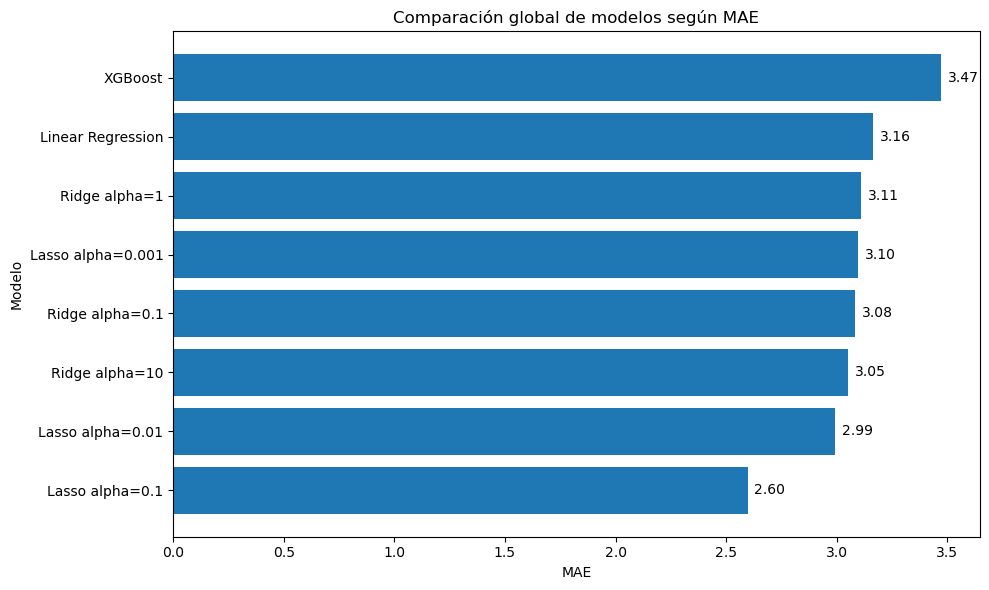

In [14]:
global_results_plot = global_results.copy()
global_results_plot = global_results_plot.sort_values("MAE", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    global_results_plot["model"],
    global_results_plot["MAE"]
)

plt.xlabel("MAE")
plt.ylabel("Modelo")
plt.title("Comparación global de modelos según MAE")

for index, value in enumerate(global_results_plot["MAE"]):
    plt.text(
        value + 0.03,
        index,
        f"{value:.2f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "global_model_comparison_mae.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

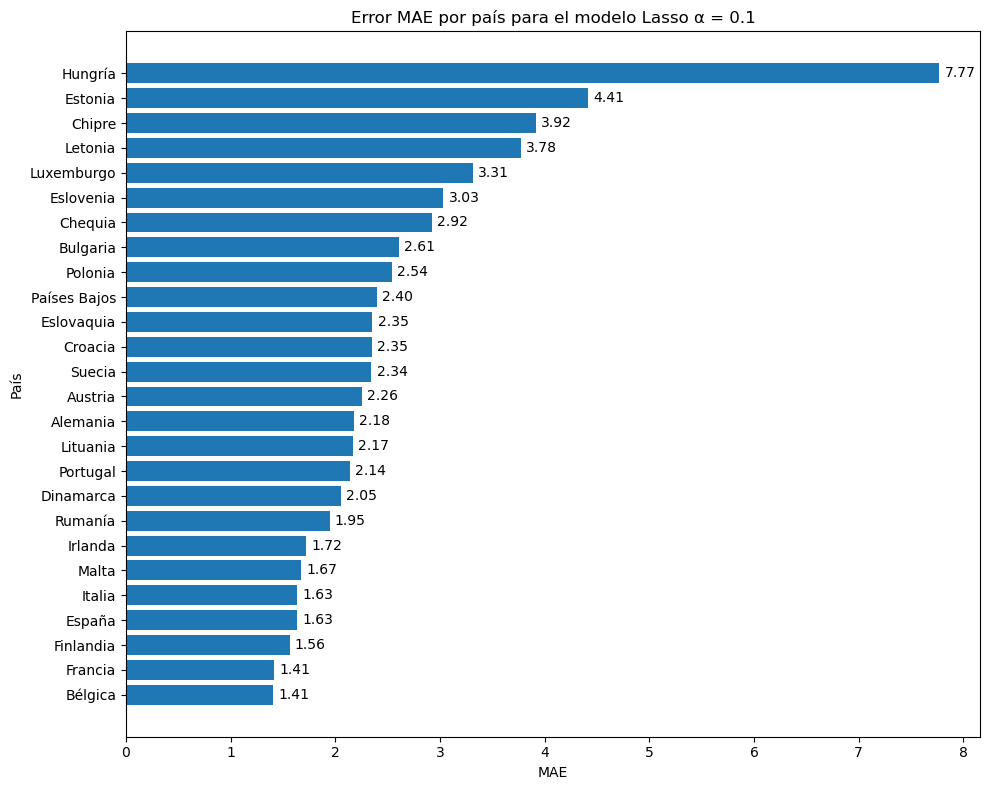

In [15]:
country_metrics_plot = country_metrics.copy()
country_metrics_plot = country_metrics_plot.sort_values("MAE", ascending=True)

plt.figure(figsize=(10, 8))

plt.barh(
    country_metrics_plot["country"],
    country_metrics_plot["MAE"]
)

plt.xlabel("MAE")
plt.ylabel("País")
plt.title("Error MAE por país para el modelo Lasso α = 0.1")

for index, value in enumerate(country_metrics_plot["MAE"]):
    plt.text(
        value + 0.05,
        index,
        f"{value:.2f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "mae_by_country_lasso_alpha_01.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

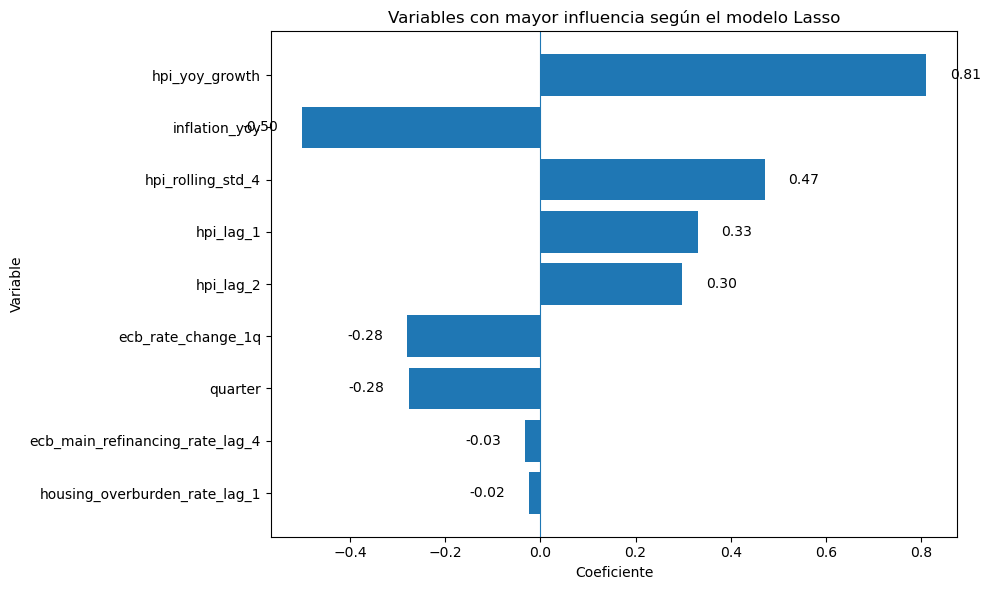

In [16]:
coef_plot = coef_df.copy()

coef_plot = coef_plot[
    coef_plot["coefficient"] != 0
].copy()

coef_plot = coef_plot[
    coef_plot["feature"] != "hpi"
]

coef_plot = coef_plot.sort_values(
    "abs_coefficient",
    ascending=False
).head(10)

coef_plot = coef_plot.sort_values(
    "abs_coefficient",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    coef_plot["feature"],
    coef_plot["coefficient"]
)

plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.title("Variables con mayor influencia según el modelo Lasso")

for index, value in enumerate(coef_plot["coefficient"]):
    offset = 0.05 if value >= 0 else -0.05
    ha = "left" if value >= 0 else "right"
    
    plt.text(
        value + offset,
        index,
        f"{value:.2f}",
        va="center",
        ha=ha
    )

plt.axvline(0, linewidth=0.8)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "lasso_feature_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()